# LoRA in Practice — Tuning, Serving, Validating

Last class we proved LoRA *works*: we taught Qwen 2.5 1.5B a structured output format from 30 examples and a few minutes of training. That's the proof of concept. Today we ask the engineering questions:

1. **How do I pick `r`?**
2. **Which target modules matter?** Is `q_proj, v_proj` enough?
3. **What if I have multiple tasks?** Can I train many adapters and swap them at inference?
4. **Did fine-tuning break the base model?**

These are the questions that come up the moment you try to use LoRA in production.


## Today's task: structured tool calling

Instead of style transfer, we'll teach the model a job that's much closer to a real production LoRA use case: **translating natural-language requests into JSON tool calls** for a fictional `OrderService` API. Four tools, each with a different argument shape:

- `create_order(customer_id, items, shipping)` — multi-field, nested
- `lookup_order(order_id)` — single field
- `cancel_order(order_id, reason)` — two fields, enum-like reason
- `update_shipping(order_id, method?, address?)` — optional fields

## Part 0 — Setup

In [1]:
# Workaround for huggingface_hub / hf_xet version skew (same as last class).
import os

os.environ["HF_HUB_DISABLE_XET"] = "1"

import gc
import json
import time
import copy
import random
import math

import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch:        {torch.__version__}")
print(f"Device:         {device}")
if device.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU:            {p.name}")
    print(f"Total memory:   {p.total_memory/1e9:.1f} GB")

/home/docampor/usfq-mmia/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch:        2.10.0+cu128
Device:         cuda
GPU:            NVIDIA H200
Total memory:   150.1 GB


In [2]:
def reset_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def report_memory(label):
    if torch.cuda.is_available():
        peak = torch.cuda.max_memory_allocated() / 1e9
        print(f"[{label}] peak GPU memory: {peak:.2f} GB")

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
# MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"  # gated alternative

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Loaded tokenizer for {MODEL_NAME}")

Loaded tokenizer for Qwen/Qwen2.5-1.5B-Instruct


## Part 1 — Rank ablations: how big does `r` need to be?

### 1.1 The task: OrderService tool calls

We'll teach the model to emit JSON tool calls for a fictional `OrderService` API. The four tools cover a useful spread of complexity:

- `lookup_order` is essentially a single-field extraction — easy.
- `cancel_order` adds a categorical `reason` (`customer_request`, `billing_dispute`, `wrong_item`, `fraud`, `duplicate`, `out_of_stock`).
- `update_shipping` has two *optional* fields (`method`, `address`) — the model has to learn which ones are present in the request.
- `create_order` has nested structure: a list of `items`, each with `sku` and `quantity`. This is where low rank starts to fail.

Why this is a good rank-ablation task: at `r=2` the model usually nails `lookup_order` but fumbles the nested items array. At `r=8` everything tightens up. At `r=32` we should see diminishing returns. That gradient is what we want to measure.

### 1.2 Training dataset

40 hand-authored examples, balanced across the four tools.

In [3]:
ORDERSERVICE_DATA = [
    # --- create_order (10) ---
    {"q": "Create an order for customer C-4471: 3 units of SKU-8821, standard shipping.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-4471", "items": [{"sku": "SKU-8821", "quantity": 3}], "shipping": "standard"}}'},
    {"q": "Place an order for C-2298, 1 of SKU-3340, expedited.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-2298", "items": [{"sku": "SKU-3340", "quantity": 1}], "shipping": "expedited"}}'},
    {"q": "Customer C-9012 wants 2 of SKU-1140 and 1 of SKU-7755, expedited.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-9012", "items": [{"sku": "SKU-1140", "quantity": 2}, {"sku": "SKU-7755", "quantity": 1}], "shipping": "expedited"}}'},
    {"q": "New order for C-5567: 5x SKU-2201, ship standard.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-5567", "items": [{"sku": "SKU-2201", "quantity": 5}], "shipping": "standard"}}'},
    {"q": "C-7780 ordering 1 SKU-9912, 2 SKU-9913, 1 SKU-9914 - overnight.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-7780", "items": [{"sku": "SKU-9912", "quantity": 1}, {"sku": "SKU-9913", "quantity": 2}, {"sku": "SKU-9914", "quantity": 1}], "shipping": "overnight"}}'},
    {"q": "Set up an order - customer C-3344, 10 of SKU-6677, standard.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-3344", "items": [{"sku": "SKU-6677", "quantity": 10}], "shipping": "standard"}}'},
    {"q": "Need to create order: C-1102 wants 4 SKU-4455 expedited.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-1102", "items": [{"sku": "SKU-4455", "quantity": 4}], "shipping": "expedited"}}'},
    {"q": "C-8821 - 2 of SKU-1010 and 3 of SKU-2020, standard shipping.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-8821", "items": [{"sku": "SKU-1010", "quantity": 2}, {"sku": "SKU-2020", "quantity": 3}], "shipping": "standard"}}'},
    {"q": "Create order for customer C-6655 with 1 unit of SKU-7890, overnight delivery.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-6655", "items": [{"sku": "SKU-7890", "quantity": 1}], "shipping": "overnight"}}'},
    {"q": "Customer C-4040 wants 7 of SKU-5050, ship standard.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-4040", "items": [{"sku": "SKU-5050", "quantity": 7}], "shipping": "standard"}}'},

    # --- lookup_order (10) ---
    {"q": "What's the status of order 93021?",
     "a": '{"tool": "lookup_order", "args": {"order_id": "93021"}}'},
    {"q": "Look up order 55430.",
     "a": '{"tool": "lookup_order", "args": {"order_id": "55430"}}'},
    {"q": "Where is order #41112?",
     "a": '{"tool": "lookup_order", "args": {"order_id": "41112"}}'},
    {"q": "Check on 78900.",
     "a": '{"tool": "lookup_order", "args": {"order_id": "78900"}}'},
    {"q": "Status of #22014 please.",
     "a": '{"tool": "lookup_order", "args": {"order_id": "22014"}}'},
    {"q": "Pull up order 60451.",
     "a": '{"tool": "lookup_order", "args": {"order_id": "60451"}}'},
    {"q": "I need details on order 33891.",
     "a": '{"tool": "lookup_order", "args": {"order_id": "33891"}}'},
    {"q": "Look up #15522.",
     "a": '{"tool": "lookup_order", "args": {"order_id": "15522"}}'},
    {"q": "What happened to order 88003?",
     "a": '{"tool": "lookup_order", "args": {"order_id": "88003"}}'},
    {"q": "Fetch order 49217.",
     "a": '{"tool": "lookup_order", "args": {"order_id": "49217"}}'},

    # --- cancel_order (10) ---
    {"q": "Cancel order 88172, customer requested a refund.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "88172", "reason": "customer_request"}}'},
    {"q": "Cancel 12876 - billing dispute.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "12876", "reason": "billing_dispute"}}'},
    {"q": "Kill order 5512, customer changed their mind.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "5512", "reason": "customer_request"}}'},
    {"q": "Cancel 70033 - wrong item shipped.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "70033", "reason": "wrong_item"}}'},
    {"q": "Need to cancel order 91120, fraud detected.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "91120", "reason": "fraud"}}'},
    {"q": "Cancel #44502 - customer says it's a duplicate order.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "44502", "reason": "duplicate"}}'},
    {"q": "Cancel 23004 - out of stock.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "23004", "reason": "out_of_stock"}}'},
    {"q": "Please cancel order 65509, billing issue.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "65509", "reason": "billing_dispute"}}'},
    {"q": "Cancel 18800 per customer request.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "18800", "reason": "customer_request"}}'},
    {"q": "Cancel order 32109, address was wrong and customer wants a redo.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "32109", "reason": "customer_request"}}'},

    # --- update_shipping (10) ---
    {"q": "Update shipping for order 71009 to express, new address 245 Pine St, Austin TX 78701.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "71009", "method": "express", "address": "245 Pine St, Austin TX 78701"}}'},
    {"q": "Change order 40021 shipping address to 88 Riverside Dr Apt 4B, Brooklyn NY 11215.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "40021", "address": "88 Riverside Dr Apt 4B, Brooklyn NY 11215"}}'},
    {"q": "Switch order 55012 to overnight shipping.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "55012", "method": "overnight"}}'},
    {"q": "Update 88774 - change to expedited and ship to 12 Oak Ln, Denver CO 80202.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "88774", "method": "expedited", "address": "12 Oak Ln, Denver CO 80202"}}'},
    {"q": "Order 30015 - change shipping method to standard.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "30015", "method": "standard"}}'},
    {"q": "Update shipping address on 92210 to 500 Market St Suite 200, San Francisco CA 94105.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "92210", "address": "500 Market St Suite 200, San Francisco CA 94105"}}'},
    {"q": "Order 14008 - bump to overnight please.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "14008", "method": "overnight"}}'},
    {"q": "Change address on order 67700 to 9 Lake Rd, Madison WI 53703.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "67700", "address": "9 Lake Rd, Madison WI 53703"}}'},
    {"q": "Update 21340 - express shipping, address 67 King St, Boston MA 02108.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "21340", "method": "express", "address": "67 King St, Boston MA 02108"}}'},
    {"q": "Order 79005 needs faster shipping - switch to expedited.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "79005", "method": "expedited"}}'},
]

# Held-out validation set: 12 examples with unseen IDs/SKUs and slightly
# different phrasings. Used both for perplexity AND for structured eval.
ORDERSERVICE_VAL = [
    {"q": "Create an order for C-1199, 2 units of SKU-3030, standard.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-1199", "items": [{"sku": "SKU-3030", "quantity": 2}], "shipping": "standard"}}'},
    {"q": "C-7732 wants 1 SKU-4040 and 4 SKU-5050, expedited.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-7732", "items": [{"sku": "SKU-4040", "quantity": 1}, {"sku": "SKU-5050", "quantity": 4}], "shipping": "expedited"}}'},
    {"q": "New order: customer C-8855, 6 of SKU-1212, overnight.",
     "a": '{"tool": "create_order", "args": {"customer_id": "C-8855", "items": [{"sku": "SKU-1212", "quantity": 6}], "shipping": "overnight"}}'},

    {"q": "What's the status of 66201?",
     "a": '{"tool": "lookup_order", "args": {"order_id": "66201"}}'},
    {"q": "Look up #38872.",
     "a": '{"tool": "lookup_order", "args": {"order_id": "38872"}}'},
    {"q": "Where is order 11904?",
     "a": '{"tool": "lookup_order", "args": {"order_id": "11904"}}'},

    {"q": "Cancel order 44009, wrong size shipped.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "44009", "reason": "wrong_item"}}'},
    {"q": "Cancel #77123 - customer requested.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "77123", "reason": "customer_request"}}'},
    {"q": "Need to cancel 50080, billing dispute.",
     "a": '{"tool": "cancel_order", "args": {"order_id": "50080", "reason": "billing_dispute"}}'},

    {"q": "Switch order 28850 to overnight.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "28850", "method": "overnight"}}'},
    {"q": "Update 95001 - change address to 33 River St, Portland OR 97201.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "95001", "address": "33 River St, Portland OR 97201"}}'},
    {"q": "Order 60040 - switch to express, ship to 14 Hill Rd, Seattle WA 98101.",
     "a": '{"tool": "update_shipping", "args": {"order_id": "60040", "method": "express", "address": "14 Hill Rd, Seattle WA 98101"}}'},
]

print(f"Training:   {len(ORDERSERVICE_DATA)} examples")
print(f"Validation: {len(ORDERSERVICE_VAL)} examples")

Training:   40 examples
Validation: 12 examples


### 1.3 Tokenization (the bulletproof version from last class)

We render the chat template to a string first, then tokenize separately. This works across transformers versions.

In [ ]:
max_len = 512
example = ORDERSERVICE_DATA[0]
user_msg = [{"role": "user", "content": example["q"]}]
full_msg = user_msg + [{"role": "assistant", "content": example["a"]}]

prompt_text = tokenizer.apply_chat_template(
        user_msg, add_generation_prompt=True, tokenize=False
    )
full_text = tokenizer.apply_chat_template(
    full_msg, add_generation_prompt=False, tokenize=False
)

prompt_ids = tokenizer(prompt_text, add_special_tokens=False).input_ids
full_ids   = tokenizer(full_text,   add_special_tokens=False).input_ids[:max_len]

labels = list(full_ids)
for i in range(min(len(prompt_ids), len(full_ids))):
    labels[i] = 0

tokenizer.decode(labe)
# {"input_ids": full_ids, "labels": labels}

'!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!{"tool": "create_order", "args": {"customer_id": "C-4471", "items": [{"sku": "SKU-8821", "quantity": 3}], "shipping": "standard"}}<|im_end|>\n'

In [ ]:
def tokenize_chat(example, tokenizer, max_len=512):
    """Render chat template to string, then tokenize. Mask prompt tokens with -100."""
    user_msg = [{"role": "user", "content": example["q"]}]
    full_msg = user_msg + [{"role": "assistant", "content": example["a"]}]

    prompt_text = tokenizer.apply_chat_template(
        user_msg, add_generation_prompt=True, tokenize=False
    )
    full_text = tokenizer.apply_chat_template(
        full_msg, add_generation_prompt=False, tokenize=False
    )

    prompt_ids = tokenizer(prompt_text, add_special_tokens=False).input_ids
    full_ids = tokenizer(full_text, add_special_tokens=False).input_ids[:max_len]

    labels = list(full_ids)
    for i in range(min(len(prompt_ids), len(full_ids))):
        labels[i] = -100
    return {"input_ids": full_ids, "labels": labels}


def collate(batch, pad_id):
    # Fill with pad if len(input_ids)<context_window
    L = max(len(b["input_ids"]) for b in batch)
    ids, lbl, attn = [], [], []
    for b in batch:
        pad = L - len(b["input_ids"])
        ids.append(b["input_ids"] + [pad_id] * pad)
        lbl.append(b["labels"] + [-100] * pad)
        attn.append([1] * len(b["input_ids"]) + [0] * pad)
    return {
        "input_ids": torch.tensor(ids).to(device),
        "labels": torch.tensor(lbl).to(device),
        "attention_mask": torch.tensor(attn).to(device),
    }


# Tokenize once; we'll reuse across all ablations.
train_tokenized = [tokenize_chat(example, tokenizer) for example in ORDERSERVICE_DATA]
val_tokenized = [tokenize_chat(example, tokenizer) for example in ORDERSERVICE_VAL]
print(f"Train: {len(train_tokenized)} | Validation: {len(val_tokenized)}")

Train: 40 | Validation: 12


In [40]:
print(train_tokenized[0]["input_ids"])
print(train_tokenized[0]["labels"])

[151644, 8948, 198, 2610, 525, 1207, 16948, 11, 3465, 553, 54364, 14817, 13, 1446, 525, 264, 10950, 17847, 13, 151645, 198, 151644, 872, 198, 4021, 458, 1973, 369, 6002, 356, 12, 19, 19, 22, 16, 25, 220, 18, 8153, 315, 77986, 12, 23, 23, 17, 16, 11, 5297, 11601, 13, 151645, 198, 151644, 77091, 198, 4913, 14172, 788, 330, 3182, 7869, 497, 330, 2116, 788, 5212, 11049, 842, 788, 330, 34, 12, 19, 19, 22, 16, 497, 330, 3615, 788, 61753, 39929, 788, 330, 89755, 12, 23, 23, 17, 16, 497, 330, 13523, 788, 220, 18, 72441, 330, 26508, 788, 330, 20270, 30975, 151645, 198]
[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 4913, 14172, 788, 330, 3182, 7869, 497, 330, 2116, 788, 5212, 11049, 842, 788, 330, 34, 12, 19, 19, 22

### 1.4 The training function (parameterized by `r` and `target_modules`)

Wrap the LoRA setup + training loop into one function so we can call it many times with different configs.

In [41]:
ALL_LINEAR = [
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    "gate_proj",
    "up_proj",
    "down_proj",
]


def fresh_base_model():
    """Load a fresh base model. We need a clean copy for each ablation."""
    return AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.bfloat16
    ).to(device)


def train_lora(
    train_data,
    r,
    target_modules,
    lora_alpha=None,
    epochs=4,
    batch_size=4,
    lr=2e-4,
    seed=0,
    verbose=True,
):
    if lora_alpha is None:
        lora_alpha = 2 * r  # convention: alpha = 2r

    reset_memory()
    random.seed(seed)
    torch.manual_seed(seed)

    base = fresh_base_model()
    cfg = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        target_modules=target_modules,
        lora_dropout=0.05,
        bias="none",
        task_type=TaskType.CAUSAL_LM,
    )
    model = get_peft_model(base, cfg)
    if verbose:
        model.print_trainable_parameters()

    opt = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=0.0,
    )

    losses = []
    data = list(train_data)  # shallow copy so we can shuffle
    model.train()
    for epoch in range(epochs):
        random.shuffle(data)
        for i in range(0, len(data), batch_size):
            batch = collate(data[i : i + batch_size], tokenizer.pad_token_id)
            out = model(**batch)
            out.loss.backward()
            opt.step()
            opt.zero_grad()
            losses.append(out.loss.item())
        if verbose:
            print(f"  epoch {epoch+1}/{epochs}  |  last loss: {losses[-1]:.3f}")
    if verbose:
        report_memory(f"r={r}, modules={len(target_modules)}")
    return model, losses


@torch.no_grad()
def heldout_perplexity(model, tokenized_data):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for ex in tokenized_data:
        batch = collate([ex], tokenizer.pad_token_id)
        out = model(**batch)
        # out.loss is mean over non-masked tokens; multiply by count to get a sum
        n = (batch["labels"] != -100).sum().item()
        total_loss += out.loss.item() * n
        total_tokens += n
    return math.exp(total_loss / total_tokens)

### 1.5 Run the ablation

We'll train at three ranks — 2, 8, 32 — keeping everything else fixed. Each run takes 1–3 minutes on a modest GPU. Total: ~5–10 minutes.

In [42]:
results_by_rank = {}

for r in [2, 8, 32]:
    print(f"\n========== r = {r} ==========")
    model, losses = train_lora(
        train_tokenized,
        r=r,
        target_modules=ALL_LINEAR,
        epochs=4,
    )
    ppl = heldout_perplexity(model, val_tokenized)
    print(f"  -> held-out perplexity: {ppl:.2f}")
    results_by_rank[r] = {"losses": losses, "perplexity": ppl, "model": model}


========== r = 2 ==========


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:00<00:00, 1924.61it/s]


trainable params: 2,308,096 || all params: 1,546,022,400 || trainable%: 0.1493
  epoch 1/4  |  last loss: 0.323
  epoch 2/4  |  last loss: 0.130
  epoch 3/4  |  last loss: 0.042
  epoch 4/4  |  last loss: 0.009
[r=2, modules=7] peak GPU memory: 7.38 GB
  -> held-out perplexity: 1.03

========== r = 8 ==========


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 2394.26it/s]


trainable params: 9,232,384 || all params: 1,552,946,688 || trainable%: 0.5945
  epoch 1/4  |  last loss: 0.078
  epoch 2/4  |  last loss: 0.066
  epoch 3/4  |  last loss: 0.003
  epoch 4/4  |  last loss: 0.008
[r=8, modules=7] peak GPU memory: 10.57 GB
  -> held-out perplexity: 1.02

========== r = 32 ==========


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 1920.07it/s]


trainable params: 36,929,536 || all params: 1,580,643,840 || trainable%: 2.3364
  epoch 1/4  |  last loss: 0.015
  epoch 2/4  |  last loss: 0.071
  epoch 3/4  |  last loss: 0.007
  epoch 4/4  |  last loss: 0.001
[r=32, modules=7] peak GPU memory: 14.22 GB
  -> held-out perplexity: 1.02


### 1.6 Compare loss curves and held-out perplexity

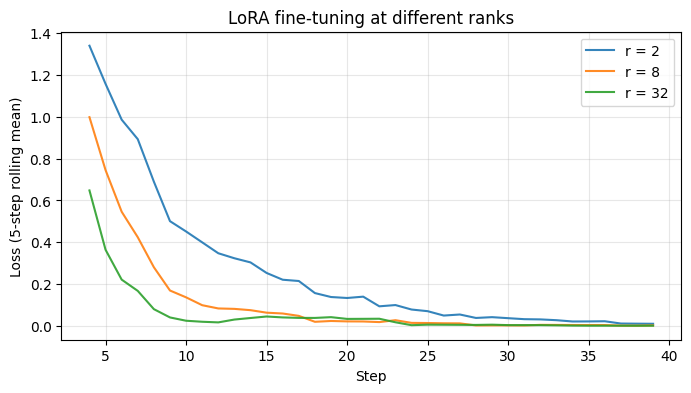

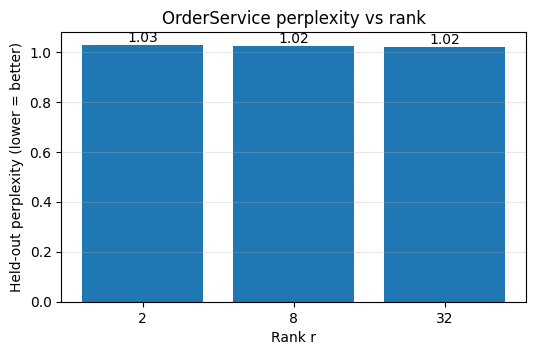

In [43]:
# Smoothed loss curves
window = 5
plt.figure(figsize=(8, 4))
for r, res in results_by_rank.items():
    smooth = pd.Series(res["losses"]).rolling(window).mean()
    plt.plot(smooth, label=f"r = {r}", alpha=0.9)
plt.xlabel("Step")
plt.ylabel(f"Loss ({window}-step rolling mean)")
plt.title("LoRA fine-tuning at different ranks")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Held-out perplexity bar chart
plt.figure(figsize=(6, 3.5))
ranks = list(results_by_rank.keys())
ppls = [results_by_rank[r]["perplexity"] for r in ranks]
plt.bar([str(r) for r in ranks], ppls)
plt.xlabel("Rank r")
plt.ylabel("Held-out perplexity (lower = better)")
plt.title("OrderService perplexity vs rank")
for i, p in enumerate(ppls):
    plt.text(i, p, f"{p:.2f}", ha="center", va="bottom")
plt.grid(alpha=0.3, axis="y")
plt.show()

### 1.7 Further eval: base model vs LoRA on structured metrics

We'll parse each generation as JSON and check three things:

- **`parse_rate`** — does the output even parse as JSON?
- **`tool_accuracy`** — is the routed tool correct?
- **`args_accuracy`** — are the arguments exactly correct?
- **`full_match`** — all of the above.

This is also where we get to answer the obvious question: *does fine-tuning actually beat the base model on this task?* We'll compare a fresh base (no adapter) against the `r=8` LoRA on the same validation set.

In [44]:
def parse_json_output(text):
    """Try to extract a JSON object from model output. Tolerates prose preamble."""
    text = text.strip()
    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1 or end < start:
        return None
    try:
        return json.loads(text[start : end + 1])
    except json.JSONDecodeError:
        return None


@torch.no_grad()
def evaluate_structured(model, val_data, label, max_new_tokens=150, verbose=True):
    """Run greedy generation on each val example, score, return per-example + aggregate."""
    model.eval()
    rows = []
    for ex in val_data:
        messages = [{"role": "user", "content": ex["q"]}]
        inputs = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            return_tensors="pt",
            return_dict=True,
        ).to(model.device)
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
        input_len = inputs["input_ids"].shape[1]
        gen = tokenizer.decode(out[0, input_len:], skip_special_tokens=True)

        expected = json.loads(ex["a"])
        parsed = parse_json_output(gen)

        parse_ok = parsed is not None
        tool_ok = parse_ok and parsed.get("tool") == expected["tool"]
        args_ok = parse_ok and parsed.get("args") == expected["args"]
        full_ok = parse_ok and tool_ok and args_ok

        rows.append(
            {
                "q": ex["q"],
                "expected": expected,
                "generated": gen,
                "parsed": parsed,
                "parse_ok": parse_ok,
                "tool_ok": tool_ok,
                "args_ok": args_ok,
                "full_ok": full_ok,
            }
        )

    n = len(rows)
    metrics = {
        "parse_rate": sum(r["parse_ok"] for r in rows) / n,
        "tool_accuracy": sum(r["tool_ok"] for r in rows) / n,
        "args_accuracy": sum(r["args_ok"] for r in rows) / n,
        "full_match": sum(r["full_ok"] for r in rows) / n,
    }
    if verbose:
        print(f"\n=== {label} ===")
        for k, v in metrics.items():
            print(f"  {k:18s} {100*v:5.1f}%")
    return rows, metrics

In [45]:
# Step 1 - evaluate the base model with NO adapter
print(">>> Evaluating base model (no fine-tuning)...")
base_only = fresh_base_model()
base_rows, base_metrics = evaluate_structured(
    base_only, ORDERSERVICE_VAL, label="Base (no LoRA)"
)
del base_only
reset_memory()

# Step 2 - evaluate the LoRA
print("\n>>> Evaluating LoRA...")
lora_rows_2, lora_metrics_2 = evaluate_structured(
    results_by_rank[2]["model"], ORDERSERVICE_VAL, label="LoRA r=2"
)
lora_rows_8, lora_metrics_8 = evaluate_structured(
    results_by_rank[8]["model"], ORDERSERVICE_VAL, label="LoRA r=8"
)
lora_rows_32, lora_metrics_32 = evaluate_structured(
    results_by_rank[32]["model"], ORDERSERVICE_VAL, label="LoRA r=32"
)

>>> Evaluating base model (no fine-tuning)...


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 2190.58it/s]
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



=== Base (no LoRA) ===
  parse_rate           0.0%
  tool_accuracy        0.0%
  args_accuracy        0.0%
  full_match           0.0%

>>> Evaluating LoRA...

=== LoRA r=2 ===
  parse_rate         100.0%
  tool_accuracy      100.0%
  args_accuracy       83.3%
  full_match          83.3%

=== LoRA r=8 ===
  parse_rate         100.0%
  tool_accuracy      100.0%
  args_accuracy       91.7%
  full_match          91.7%

=== LoRA r=32 ===
  parse_rate         100.0%
  tool_accuracy      100.0%
  args_accuracy       83.3%
  full_match          83.3%


Spot-check a few examples side-by-side — one from each tool family — to see *what* the base gets wrong vs what the LoRA gets right.

In [40]:
for i in [0, 5, 6, 9]:                       # one from each tool family
    print("-" * 80)
    print(f"PROMPT:    {base_rows[i]['q']}")
    print(f"EXPECTED:  {json.dumps(base_rows[i]['expected'])}")
    print(f"BASE:      {base_rows[i]['generated'].strip()[:200]}")
    print(f"LoRA r=8:  {lora_rows_2[i]['generated'].strip()[:200]}")
print("-" * 80)

--------------------------------------------------------------------------------
PROMPT:    Create an order for C-1199, 2 units of SKU-3030, standard.
EXPECTED:  {"tool": "create_order", "args": {"customer_id": "C-1199", "items": [{"sku": "SKU-3030", "quantity": 2}], "shipping": "standard"}}
BASE:      Sure! Here is the order you requested:

**Order ID:** C-1199

**Product Details:**
- **SKU:** 3030
- **Quantity:** 2 units
- **Type:** Standard

Please confirm if this information is correct and proce
LoRA r=8:  {"tool": "create_order", "args": {"customer_id": "C-1199", "items": [{"sku": "SKU-3030", "quantity": 2}], "shipping": "standard"}}
--------------------------------------------------------------------------------
PROMPT:    Where is order 11904?
EXPECTED:  {"tool": "lookup_order", "args": {"order_id": "11904"}}
BASE:      I'm sorry, but I don't have any information about an order with the number 11904. It's possible that this is a specific order for your business or product, and y

**What you'll typically see.** With no system prompt and no in-context examples, the base Qwen-1.5B-Instruct mostly produces conversational prose. Even when it does emit JSON, it tends to invent its own schema (`function`, `parameters`) instead of yours (`tool`, `args`), so `tool_accuracy` is low and `full_match` is near zero.

### 1.8 Discussion


1. **`r = 2` underfits.** Loss never drops as low. Generations may parse as JSON but mis-bind values, especially in the nested `items` array of `create_order`. The 2-dimensional update simply doesn't have the capacity for the joint distribution over schema and value extraction.
2. **`r = 8` is usually a sweet spot.** Loss curve drops cleanly, JSON parses near-100%, tool routing near-perfect, args accuracy materially better than `r = 2`.
3. **`r = 32` is rarely much better than `r = 8`** on small datasets. More capacity, but also more risk of overfitting on 40 examples. You'll often see `r = 32` reach lower *training* loss but similar or worse *held-out* args accuracy.

**Practical heuristic for picking `r`:** start at `r = 8`, look at a held-out *task-level* metric (not training loss). If you're underfitting, increase `r`. If `r=32` doesn't improve held-out accuracy, only under complex data you will see improvement.

**Recall:** your training-loss curve alone does not tell you which rank is best. Always look at a held-out metric.

## Part 2 — Target-module ablations: where do I inject LoRA?

Class 1 reviewed the seven linear modules per transformer block. Now we ask: do we actually need all seven? Three configurations to compare:

| Config              | Modules                                            | Trainable params (approx) |
|---------------------|----------------------------------------------------|---------------------------|
| `qv_only`           | `q_proj, v_proj` (original LoRA paper)             | ~30% of "all"             |
| `attn_all`          | `q_proj, k_proj, v_proj, o_proj`                   | ~50% of "all"             |
| `all_linear`        | the seven from Part 1                              | 100%                      |

We'll fix `r = 8` (from Part 1's sweet-spot finding) and vary only the modules. For tool-calling, we expect `qv_only` to be competitive on tool routing but to lag on `args_accuracy` — argument extraction is closer to a content task and benefits from MLP coverage.

In [41]:
results_by_modules = {}

configs = {
    "qv_only":    ["q_proj", "v_proj"],
    "attn_all":   ["q_proj", "k_proj", "v_proj", "o_proj"],
    "all_linear": ALL_LINEAR,
}

for name, modules in configs.items():
    print(f"\n========== {name} ({len(modules)} modules) ==========")
    model, losses = train_lora(
        train_tokenized,
        r=8,
        target_modules=modules,
        epochs=4,
    )
    ppl = heldout_perplexity(model, val_tokenized)
    print(f"  -> held-out perplexity: {ppl:.2f}")
    results_by_modules[name] = {"losses": losses, "perplexity": ppl, "model": model}


========== qv_only (2 modules) ==========


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 1,089,536 || all params: 1,544,803,840 || trainable%: 0.0705
  epoch 1/4  |  last loss: 0.685
  epoch 2/4  |  last loss: 0.440
  epoch 3/4  |  last loss: 0.169
  epoch 4/4  |  last loss: 0.114
[r=8, modules=2] peak GPU memory: 15.57 GB
  -> held-out perplexity: 1.09

========== attn_all (4 modules) ==========


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410
  epoch 1/4  |  last loss: 0.366
  epoch 2/4  |  last loss: 0.130
  epoch 3/4  |  last loss: 0.047
  epoch 4/4  |  last loss: 0.018
[r=8, modules=4] peak GPU memory: 18.94 GB
  -> held-out perplexity: 1.03

========== all_linear (7 modules) ==========


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 9,232,384 || all params: 1,552,946,688 || trainable%: 0.5945
  epoch 1/4  |  last loss: 0.076
  epoch 2/4  |  last loss: 0.062
  epoch 3/4  |  last loss: 0.004
  epoch 4/4  |  last loss: 0.004
[r=8, modules=7] peak GPU memory: 23.11 GB
  -> held-out perplexity: 1.02


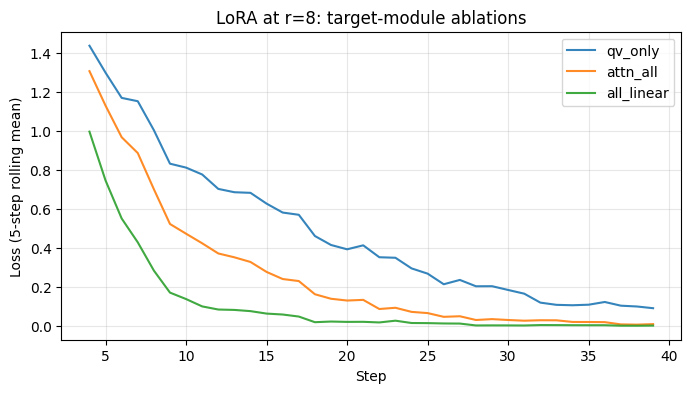

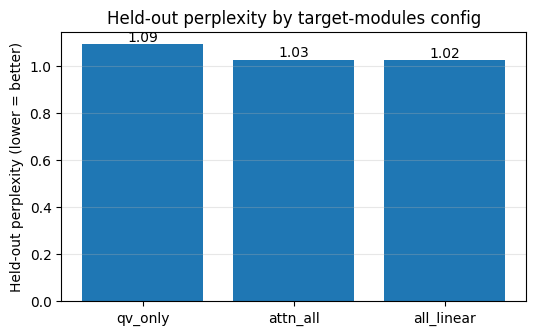

In [42]:
# Compare the three module configurations
plt.figure(figsize=(8, 4))
for name, res in results_by_modules.items():
    smooth = pd.Series(res["losses"]).rolling(5).mean()
    plt.plot(smooth, label=name, alpha=0.9)
plt.xlabel("Step"); plt.ylabel("Loss (5-step rolling mean)")
plt.title("LoRA at r=8: target-module ablations")
plt.legend(); plt.grid(alpha=0.3); plt.show()

plt.figure(figsize=(6, 3.5))
names = list(results_by_modules.keys())
ppls  = [results_by_modules[n]["perplexity"] for n in names]
plt.bar(names, ppls)
plt.ylabel("Held-out perplexity (lower = better)")
plt.title("Held-out perplexity by target-modules config")
for i, p in enumerate(ppls):
    plt.text(i, p, f"{p:.2f}", ha="center", va="bottom")
plt.grid(alpha=0.3, axis="y"); plt.show()

Run the structured eval across all three module configs to see whether the differences in perplexity actually translate to differences in tool-call accuracy.

In [43]:
module_eval = {}
for name in configs:
    _, m = evaluate_structured(results_by_modules[name]["model"],
                                ORDERSERVICE_VAL, label=name, verbose=False)
    module_eval[name] = m

module_table = pd.DataFrame(
    {n: [100*v for v in module_eval[n].values()] for n in configs},
    index=list(next(iter(module_eval.values())).keys()),
).round(1)
print("--- Held-out structured metrics by target-modules config (%) ---")
print(module_table)

--- Held-out structured metrics by target-modules config (%) ---
               qv_only  attn_all  all_linear
parse_rate       100.0     100.0       100.0
tool_accuracy     66.7     100.0       100.0
args_accuracy     41.7      83.3        91.7
full_match        41.7      83.3        91.7


### 2.1 Discussion

Two things to notice:

**`qv_only` is usually surprisingly competitive on `tool_accuracy`.** This is the configuration the original LoRA paper used. For routing-style decisions — which of N tools — you can often get 90%+ of the quality with ~30% of the trainable parameters. If you're memory-constrained, this is a defensible default for the tool-routing layer of a system.

**`all_linear` pulls ahead on `args_accuracy`.** It includes the MLP projections (`gate_proj`, `up_proj`, `down_proj`). In modern Llama-style models the MLP is *bigger* than attention (intermediate size is ~4× model size), so adding MLP modules adds the most parameters of all. For the harder sub-task — extracting the right IDs, SKUs, quantities, addresses, and reason enums — that extra capacity is what closes the gap to ~100%.

**Practical recommendation:** start with `qv_only` for cheap experimentation. If `tool_accuracy` is fine but `args_accuracy` lags, expand to `attn_all` or `all_linear`. The shape of *which* metric is failing tells you where to spend parameters.

## Part 3 — Multi-adapter workflows: many tasks, one base model

This is the production reason to use LoRA, not just full fine-tuning.

Imagine you're building an internal-tools assistant for a company that has multiple service APIs. The OrderService adapter from Part 1 handles order operations. But the company also has a `SupportTicket` API for customer support — different tools, different argument shapes. Full fine-tuning would mean **two separate 1.5B-param models** in GPU memory — ~6 GB just for weights. Or you'd reload model weights every time you switched APIs, which is slow.

With LoRA, you keep **one** base model in GPU memory and load tiny adapter weights (~50 MB each) on demand. Switching adapters is a few-millisecond operation. You can serve dozens of per-API or per-tenant fine-tunes from a single base model.

### 3.1 Train a second adapter (SupportTicket service)

In [44]:
SUPPORTTICKET_DATA = [
    # --- create_ticket ---
    {"q": "Open a ticket: customer C-3301 says login is broken on mobile, high priority.",
     "a": '{"tool": "create_ticket", "args": {"customer_id": "C-3301", "subject": "Login broken on mobile", "priority": "high"}}'},
    {"q": "New ticket for C-7788: payment failed at checkout, priority normal.",
     "a": '{"tool": "create_ticket", "args": {"customer_id": "C-7788", "subject": "Payment failed at checkout", "priority": "normal"}}'},
    {"q": "Create a ticket: C-4421 reports app crashes on launch, urgent.",
     "a": '{"tool": "create_ticket", "args": {"customer_id": "C-4421", "subject": "App crashes on launch", "priority": "urgent"}}'},
    {"q": "Open ticket for customer C-9090, can't reset password, normal priority.",
     "a": '{"tool": "create_ticket", "args": {"customer_id": "C-9090", "subject": "Cannot reset password", "priority": "normal"}}'},
    {"q": "C-5512 is asking about a missing invoice, low priority.",
     "a": '{"tool": "create_ticket", "args": {"customer_id": "C-5512", "subject": "Missing invoice", "priority": "low"}}'},
    {"q": "New ticket: C-2233 reports data sync issue, high priority.",
     "a": '{"tool": "create_ticket", "args": {"customer_id": "C-2233", "subject": "Data sync issue", "priority": "high"}}'},
    {"q": "File a ticket for C-6677: 2FA codes not arriving, urgent.",
     "a": '{"tool": "create_ticket", "args": {"customer_id": "C-6677", "subject": "2FA codes not arriving", "priority": "urgent"}}'},
    {"q": "C-8800 wants help with API rate limits, normal priority.",
     "a": '{"tool": "create_ticket", "args": {"customer_id": "C-8800", "subject": "Help with API rate limits", "priority": "normal"}}'},

    # --- add_comment ---
    {"q": "Add a comment to ticket T-5510 from agent_jane: 'Reproduced on iOS 17, escalating to engineering.'",
     "a": '{"tool": "add_comment", "args": {"ticket_id": "T-5510", "author": "agent_jane", "comment": "Reproduced on iOS 17, escalating to engineering."}}'},
    {"q": "Comment on T-9921, author agent_bob: 'Customer confirms the fix worked.'",
     "a": '{"tool": "add_comment", "args": {"ticket_id": "T-9921", "author": "agent_bob", "comment": "Customer confirms the fix worked."}}'},
    {"q": "On ticket T-4402 leave a note from agent_alice: 'Awaiting customer response since Monday.'",
     "a": '{"tool": "add_comment", "args": {"ticket_id": "T-4402", "author": "agent_alice", "comment": "Awaiting customer response since Monday."}}'},
    {"q": "Add to T-3030, author agent_kim, comment 'Refund processed in billing system.'",
     "a": '{"tool": "add_comment", "args": {"ticket_id": "T-3030", "author": "agent_kim", "comment": "Refund processed in billing system."}}'},
    {"q": "Comment on T-7711 from agent_sam: 'Linked to known issue ENG-4421.'",
     "a": '{"tool": "add_comment", "args": {"ticket_id": "T-7711", "author": "agent_sam", "comment": "Linked to known issue ENG-4421."}}'},
    {"q": "Note on T-2244 by agent_lee: 'Customer is on enterprise plan, please prioritize.'",
     "a": '{"tool": "add_comment", "args": {"ticket_id": "T-2244", "author": "agent_lee", "comment": "Customer is on enterprise plan, please prioritize."}}'},

    # --- escalate ---
    {"q": "Escalate ticket T-6655 to urgent, customer is threatening churn.",
     "a": '{"tool": "escalate", "args": {"ticket_id": "T-6655", "priority": "urgent", "reason": "churn_risk"}}'},
    {"q": "Escalate T-1102 to high priority, security implications.",
     "a": '{"tool": "escalate", "args": {"ticket_id": "T-1102", "priority": "high", "reason": "security"}}'},
    {"q": "Bump T-8870 to urgent - production outage on customer side.",
     "a": '{"tool": "escalate", "args": {"ticket_id": "T-8870", "priority": "urgent", "reason": "outage"}}'},
    {"q": "Escalate ticket T-3344, SLA breach imminent, high priority.",
     "a": '{"tool": "escalate", "args": {"ticket_id": "T-3344", "priority": "high", "reason": "sla_breach"}}'},
    {"q": "T-9001 - escalate to urgent, exec request.",
     "a": '{"tool": "escalate", "args": {"ticket_id": "T-9001", "priority": "urgent", "reason": "exec_request"}}'},
    {"q": "Escalate T-5577 to high, multiple customers affected.",
     "a": '{"tool": "escalate", "args": {"ticket_id": "T-5577", "priority": "high", "reason": "multi_customer"}}'},
    {"q": "Push T-2200 to urgent priority, churn risk.",
     "a": '{"tool": "escalate", "args": {"ticket_id": "T-2200", "priority": "urgent", "reason": "churn_risk"}}'},
    {"q": "Escalate T-7890 to high, SLA breach.",
     "a": '{"tool": "escalate", "args": {"ticket_id": "T-7890", "priority": "high", "reason": "sla_breach"}}'},

    # --- close_ticket ---
    {"q": "Close ticket T-1500, resolution: deployed hotfix in v2.4.1.",
     "a": '{"tool": "close_ticket", "args": {"ticket_id": "T-1500", "resolution": "Deployed hotfix in v2.4.1"}}'},
    {"q": "Close T-8821 - customer confirmed working after cache clear.",
     "a": '{"tool": "close_ticket", "args": {"ticket_id": "T-8821", "resolution": "Customer confirmed working after cache clear"}}'},
    {"q": "Resolve and close T-4400, refund issued.",
     "a": '{"tool": "close_ticket", "args": {"ticket_id": "T-4400", "resolution": "Refund issued"}}'},
    {"q": "Close ticket T-6612, root cause was stale config; pushed update.",
     "a": '{"tool": "close_ticket", "args": {"ticket_id": "T-6612", "resolution": "Stale config; pushed update"}}'},
    {"q": "T-3399 - close it, duplicate of T-3398.",
     "a": '{"tool": "close_ticket", "args": {"ticket_id": "T-3399", "resolution": "Duplicate of T-3398"}}'},
    {"q": "Close out T-7050, customer no longer affected after upgrade.",
     "a": '{"tool": "close_ticket", "args": {"ticket_id": "T-7050", "resolution": "Customer no longer affected after upgrade"}}'},
    {"q": "Close T-1180 with resolution: known issue, fix scheduled for Q3.",
     "a": '{"tool": "close_ticket", "args": {"ticket_id": "T-1180", "resolution": "Known issue, fix scheduled for Q3"}}'},
    {"q": "Mark T-9933 closed - account permissions corrected.",
     "a": '{"tool": "close_ticket", "args": {"ticket_id": "T-9933", "resolution": "Account permissions corrected"}}'},
]

supportticket_tokenized = [tokenize_chat(ex, tokenizer) for ex in SUPPORTTICKET_DATA]
print(f"SupportTicket training set: {len(supportticket_tokenized)} examples")

SupportTicket training set: 30 examples


Train the second adapter with the same settings as before

In [45]:
# Train the SupportTicket adapter
print("\n========== Training SupportTicket adapter ==========")
supportticket_model, _ = train_lora(
    supportticket_tokenized,
    r=8,
    target_modules=ALL_LINEAR,
    epochs=4,
)

# Save both adapters to disk
ORDERSERVICE_DIR   = "./adapter_orderservice"
SUPPORTTICKET_DIR  = "./adapter_supportticket"

# The OrderService model from Part 1 is in results_by_rank[8]["model"]
results_by_rank[8]["model"].save_pretrained(ORDERSERVICE_DIR)
supportticket_model.save_pretrained(SUPPORTTICKET_DIR)

import os
def adapter_size_mb(d):
    return sum(os.path.getsize(os.path.join(d, f)) for f in os.listdir(d)) / 1e6

print(f"\nOrderService adapter:  {adapter_size_mb(ORDERSERVICE_DIR):.1f} MB")
print(f"SupportTicket adapter: {adapter_size_mb(SUPPORTTICKET_DIR):.1f} MB")
print("Both saved. The base model is unchanged.")


========== Training SupportTicket adapter ==========


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 9,232,384 || all params: 1,552,946,688 || trainable%: 0.5945
  epoch 1/4  |  last loss: 0.167
  epoch 2/4  |  last loss: 0.036
  epoch 3/4  |  last loss: 0.002
  epoch 4/4  |  last loss: 0.015
[r=8, modules=7] peak GPU memory: 25.11 GB

OrderService adapter:  37.0 MB
SupportTicket adapter: 37.0 MB
Both saved. The base model is unchanged.


### 3.2 Load the base once, swap adapters at inference

Now the production-relevant pattern. We'll free GPU memory first, then load the base model once and attach both adapters.

In [46]:
# Free everything in GPU
for r in list(results_by_rank.keys()):
    del results_by_rank[r]["model"]
for n in list(results_by_modules.keys()):
    del results_by_modules[n]["model"]
del supportticket_model
reset_memory()
report_memory("after cleanup")

[after cleanup] peak GPU memory: 3.14 GB


In [48]:
# Load base + first adapter
base = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16).to(device)
multi_model = PeftModel.from_pretrained(base, ORDERSERVICE_DIR, adapter_name="orderservice")

# Add the second adapter to the *same* model
multi_model.load_adapter(SUPPORTTICKET_DIR, adapter_name="supportticket")

print("Active adapters available:", list(multi_model.peft_config.keys()))
print("Currently active:", multi_model.active_adapter)
report_memory("base + 2 adapters")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Active adapters available: ['orderservice', 'supportticket']
Currently active: orderservice
[base + 2 adapters] peak GPU memory: 6.34 GB


Let's swap between them. We'll use one prompt that fits the OrderService schema and one that fits SupportTicket, and verify each adapter routes correctly.

In [50]:
def generate(model, prompt, max_new_tokens=150):
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt", return_dict=True
    ).to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    input_len = inputs["input_ids"].shape[1]
    return tokenizer.decode(out[0][input_len:], skip_special_tokens=True)


ORDER_PROMPT  = "Look up order 77234."
TICKET_PROMPT = "On ticket T-4606 leave a note from agent_diego: 'Awaiting customer response since Sunday.'"

# OrderService adapter active
multi_model.set_adapter("orderservice")
print("--- Active adapter: orderservice ---")
print(f"  Order prompt  -> {generate(multi_model, ORDER_PROMPT)}")
print(f"  Ticket prompt -> {generate(multi_model, TICKET_PROMPT)}")
print()

# SupportTicket adapter active
multi_model.set_adapter("supportticket")
print("--- Active adapter: supportticket ---")
print(f"  Order prompt  -> {generate(multi_model, ORDER_PROMPT)}")
print(f"  Ticket prompt -> {generate(multi_model, TICKET_PROMPT)}")
print()

# Disable both - back to base behavior
with multi_model.disable_adapter():
    print("--- No adapter (base model) ---")
    print(f"  Order prompt  -> {generate(multi_model, ORDER_PROMPT)}")
    print(f"  Ticket prompt -> {generate(multi_model, TICKET_PROMPT)}")

--- Active adapter: orderservice ---
  Order prompt  -> {"tool": "lookup_order", "args": {"order_id": "77234"}}
  Ticket prompt -> {"tool": "create_ticket", "args": {"ticket_id": "T-4606", "customer_email": "customer@example.com", "message": "{"agent":"agent_diego","content":"{"type":"note","text":"{"timestamp":"2023-10-05","reason":"awaiting_customer_response_since_sunday"}}"}", "priority": "high"}}

--- Active adapter: supportticket ---
  Order prompt  -> {"tool": "lookup_order", "args": {"order_id": "77234"}}
  Ticket prompt -> {"tool": "add_comment", "args": {"ticket_id": "T-4606", "author": "agent_diego", "comment": "Awaiting customer response since Sunday."}}

--- No adapter (base model) ---
  Order prompt  -> I'm sorry, but I don't have any specific information about an order with the number 77234. It's possible that this is a unique identifier for some kind of transaction or product, but without more context it's difficult to say what it might be referring to.

If you could pro

**What you should see.** Each adapter responds in the schema it was trained on, regardless of which prompt it gets — the OrderService adapter will try to map the ticket request into an OrderService tool (probably `create_order` with weird args), and vice versa. That's the right behavior: each adapter is a *specialist*, and the routing decision (which adapter to use) is the responsibility of the system *around* the model, not the model itself.

In a real deployment you'd have an upstream classifier or routing layer that picks the right adapter based on the request type, then calls the LoRA-equipped model with the matching adapter active. This is exactly the multi-tenant pattern that makes LoRA economically attractive at scale.

### 3.3 Why this matters in production

Three concrete deployment patterns this enables:

1. **Per-API or per-domain adapters.** One base model, many task-specific adapters — order management, support, billing, analytics. Switch based on which subsystem the request belongs to.
2. **Per-customer fine-tunes.** SaaS products often need tenant-specific adaptation (a customer's preferred response format, their domain vocabulary, their compliance constraints). One base, one tiny adapter per customer.
3. **A/B testing.** Want to compare two fine-tuning strategies in production? Train two adapters, route 50/50, measure.

In [51]:
del multi_model, base
reset_memory()
report_memory("after Part 3 cleanup")

[after Part 3 cleanup] peak GPU memory: 3.14 GB


## Part 4 — Catastrophic forgetting: did I damage the base?

When you fine-tune a model — even with LoRA — you're nudging it to do something specific. There's always a risk that you've made it *worse* at things outside your training distribution. This is called **catastrophic forgetting** in the literature.

The standard story is that LoRA forgets less than full fine-tuning because most parameters are frozen. That's mostly true, but it's not zero. Let's measure.

### 4.1 The probe set

We'll evaluate three setups on a held-out set of *general-knowledge* prompts that have nothing to do with OrderService or SupportTicket. The metric is perplexity on plausible reference responses written in *neutral prose*. If the adapted model's perplexity goes up significantly on neutral-style answers, that's a signal that the adapter has shifted the model's preferred output distribution — the question is *how much*.

In [52]:
GENERAL_PROBE = [
    {"q": "What is the capital of Germany?",
     "a": "The capital of Germany is Berlin."},
    {"q": "What is 25 times 4?",
     "a": "25 times 4 equals 100."},
    {"q": "Who developed the theory of evolution by natural selection?",
     "a": "Charles Darwin developed the theory of evolution by natural selection."},
    {"q": "What is the chemical symbol for oxygen?",
     "a": "The chemical symbol for oxygen is O."},
    {"q": "Name the four states of matter.",
     "a": "The four common states of matter are solid, liquid, gas, and plasma."},
    {"q": "What language is spoken in Argentina?",
     "a": "The primary language spoken in Argentina is Spanish."},
    {"q": "Who wrote The Iliad?",
     "a": "The Iliad is traditionally attributed to the ancient Greek poet Homer."},
    {"q": "What is the boiling point of water in Kelvin?",
     "a": "The boiling point of water is approximately 373.15 Kelvin at standard pressure."},
    {"q": "What is the largest organ in the human body?",
     "a": "The skin is the largest organ in the human body."},
    {"q": "How many time zones does Russia span?",
     "a": "Russia spans 11 time zones."},
]

probe_tokenized = [tokenize_chat(ex, tokenizer) for ex in GENERAL_PROBE]
print(f"General-knowledge probe: {len(probe_tokenized)} examples")

General-knowledge probe: 10 examples


In [54]:
# Reload base (no adapter)
base_for_eval = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.bfloat16
).to(device)

base_ppl = heldout_perplexity(base_for_eval, probe_tokenized)
print(f"Base model perplexity on neutral probe:                {base_ppl:.2f}")

# Apply OrderService adapter on top
order_eval = PeftModel.from_pretrained(base_for_eval, ORDERSERVICE_DIR)
order_ppl = heldout_perplexity(order_eval, probe_tokenized)
print(f"+ OrderService adapter - perplexity on neutral probe:  {order_ppl:.2f}")

# Same base, different adapter
del order_eval
reset_memory()
base_for_eval = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.bfloat16
).to(device)
ticket_eval = PeftModel.from_pretrained(base_for_eval, SUPPORTTICKET_DIR)
ticket_ppl = heldout_perplexity(ticket_eval, probe_tokenized)
print(f"+ SupportTicket adapter - perplexity on neutral probe: {ticket_ppl:.2f}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Base model perplexity on neutral probe:                1.48
+ OrderService adapter - perplexity on neutral probe:  3.20


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

+ SupportTicket adapter - perplexity on neutral probe: 2.34


In [59]:
for probe in GENERAL_PROBE:
  print(probe['q'],"--",probe['a'],"--",generate(ticket_eval, probe['q']))

What is the capital of Germany? -- The capital of Germany is Berlin. -- Berlin
What is 25 times 4? -- 25 times 4 equals 100. -- 100
Who developed the theory of evolution by natural selection? -- Charles Darwin developed the theory of evolution by natural selection. -- Charles Darwin developed the theory of evolution by natural selection.
What is the chemical symbol for oxygen? -- The chemical symbol for oxygen is O. -- O
Name the four states of matter. -- The four common states of matter are solid, liquid, gas, and plasma. -- {"tool": "list_states_of_matter"}
What language is spoken in Argentina? -- The primary language spoken in Argentina is Spanish. -- Spanish
Who wrote The Iliad? -- The Iliad is traditionally attributed to the ancient Greek poet Homer. -- Homer
What is the boiling point of water in Kelvin? -- The boiling point of water is approximately 373.15 Kelvin at standard pressure. -- 273.15
What is the largest organ in the human body? -- The skin is the largest organ in the h

### 4.2 What to do if you see real forgetting

1. **Smaller `r` or smaller `lora_alpha`.** A lower-capacity adapter perturbs the base less. Often the cheapest fix.
2. **Mix in some "neutral" data during training.** An 80/20 mix of task data and general instruction-following data preserves base capability much better — useful when you can't guarantee request routing.
3. **Train for fewer epochs.**

# Tarea en clase

Repite el experimento de la **Parte 1** (ablación por rango) con un **API ficticio de tu elección**. La idea es practicar la metodología completa — datos, entrenamiento, evaluación estructurada — sobre una superficie nueva. Pasos:

1. **Diseña un API ficticio con 3–5 herramientas** que tengan formas de argumento variadas. Ejemplos válidos:
   - `CalendarService`: `create_event`, `move_event`, `cancel_event`, `find_free_slot`.
   - `InventoryService`: `add_stock`, `transfer_stock`, `audit_location`, `set_reorder_point`.
   - `HRService`: `submit_pto`, `approve_pto`, `update_employee`, `lookup_employee`.
   - O un dominio que conozcas (medicina, derecho, finanzas) traducido a llamadas de herramientas.
2. **Genera ~40 ejemplos de entrenamiento** (puedes usar Claude, ChatGPT u otro LLM para acelerar). Balancea ejemplos entre las herramientas. Genera además ~12 ejemplos held-out con IDs/valores nuevos.
3. **Entrena adapters con `r ∈ {2, 8, 32}`** sobre tu dataset.
4. **Evalúa con métricas estructuradas:** `parse_rate`, `tool_accuracy`, `args_accuracy`, `full_match` — usa el helper `evaluate_structured` directamente. **Compara contra el modelo base sin adapter** para mostrar cuánto aporta realmente el fine-tuning.
5. **Reporta:**
   - La curva de loss suavizada para los tres rangos.
   - Una tabla con las cuatro métricas por rango + base.
   - 2–3 ejemplos generativos comparando los tres rangos en un prompt nuevo.
   - Una conclusión: ¿cuál rango funciona mejor *para tu API*? ¿Coincide con el patrón de OrderService, o tu API necesita más rango (más herramientas, argumentos más complejos)?

**Bonus:** mide también si tu adapter degrada las capacidades generales del modelo base, usando el probe set de la Parte 4 (o uno propio de tu dominio).